# Quantitative Investing: Multiple Technical Indicator Trading Strategy

###  By: Drew Glover

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
import datetime as dt
import requests
from io import StringIO
from math import floor
import seaborn as sns

sns.set()

plt.style.use('fivethirtyeight')
plt.rcParams['figure.figsize'] = (20,10)

## Stock Trading using Multiple Technical Indicators 

In [2]:
headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'}
url = 'https://en.wikipedia.org/wiki/Nasdaq-100'
response = requests.get(url, headers=headers)

# Parse HTML from the response text
df = pd.read_html(StringIO(response.text))[4]
tickers = df['Ticker'].to_list()

stocks_list = []

for ticker in tickers:
    try:
        data = yf.download(ticker, start='2020-01-01', end=dt.date.today(), 
                           progress=False, auto_adjust=True)
        # Flatten MultiIndex columns if present
        if isinstance(data.columns, pd.MultiIndex):
            data.columns = data.columns.get_level_values(0)
        data['ticker'] = ticker
        stocks_list.append(data)
    except Exception as e:
        print(f"Skipping {ticker}: {e}")

stocks = pd.concat(stocks_list)

# Fix the FutureWarning by specifying fill_method=None
stocks['returns'] = stocks.groupby('ticker')['Close'].pct_change(fill_method=None)
stocks.head()

Price,Close,High,Low,Open,Volume,ticker,returns
Date,,,,,,,
2020-01-02,334.429993,334.480011,329.170013,330.000000,1990100,ADBE,NaN
2020-01-03,331.809998,332.980011,328.690002,329.170013,1577600,ADBE,-0.007834
2020-01-06,333.709991,333.910004,328.190002,328.290009,1874700,ADBE,0.005726
2020-01-07,333.390015,334.790009,332.309998,334.149994,2500800,ADBE,-0.000959
2020-01-08,337.869995,339.230011,333.399994,333.809998,2248500,ADBE,0.013438


# All Indicators Below

In [3]:
#For all strategy "position" columns (1=buy, 0=hold, -1=sell)

## Simple Moving Average (Price)

In [4]:
#Short term window Moving Avg (1 trading week)
stocks['SMA_5'] = stocks.groupby('ticker')['Close'].transform(lambda x: x.rolling(window = 5).mean())
#Long term window Moving Avg (1 trading month)
stocks['SMA_20'] = stocks.groupby('ticker')['Close'].transform(lambda x: x.rolling(window = 20).mean())
#Check for Golden Cross (when short term moving average crosses above long term), aka: when the ratio < 1
stocks['SMA_Ratio'] = stocks['SMA_20'] / stocks['SMA_5']

#Strategy:
#If SMA_Ratio < 1 THEN BUY

#Create a position column where (1=buy, 0=hold, -1=sell)
stocks['SMA_Indicator_Action'] = np.where(stocks['SMA_Ratio'] < 1, 1.0,0.0)
stocks['SMA_Indicator_Position'] = stocks['SMA_Indicator_Action'].diff()

### Example Plot

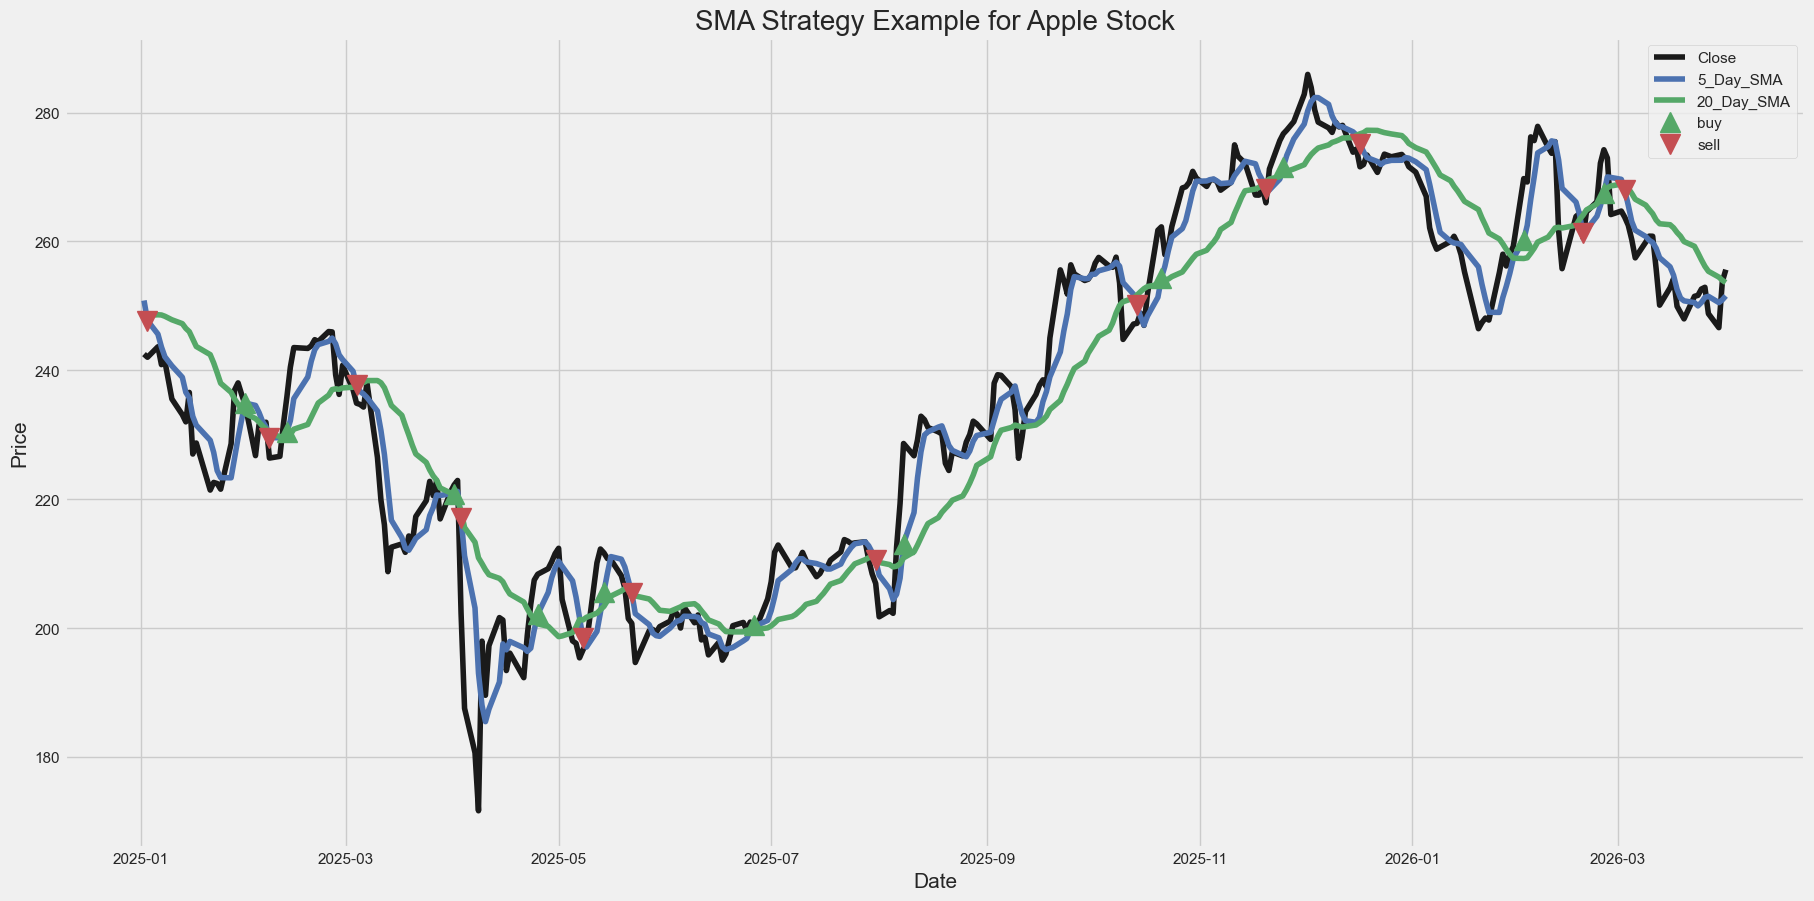

In [5]:
aapl = stocks[stocks['ticker'] == 'AAPL']
aapl = aapl[aapl.index > '2025-01-01']

plt.figure(figsize=(20, 10))

plt.plot(aapl.index, aapl['Close'], color='k', label='Close')
plt.plot(aapl.index, aapl['SMA_5'], color='b', label='5_Day_SMA')
plt.plot(aapl.index, aapl['SMA_20'], color='g', label='20_Day_SMA')

# Plot buy signals
plt.plot(aapl[aapl['SMA_Indicator_Position'] == 1].index,
         aapl['SMA_5'][aapl['SMA_Indicator_Position'] == 1],
         '^', markersize=15, color='g', label='buy')

# Plot sell signals
plt.plot(aapl[aapl['SMA_Indicator_Position'] == -1].index,
         aapl['SMA_5'][aapl['SMA_Indicator_Position'] == -1],
         'v', markersize=15, color='r', label='sell')

plt.ylabel('Price', fontsize=15)
plt.xlabel('Date', fontsize=15)
plt.title('SMA Strategy Example for Apple Stock', fontsize=20)
plt.legend()
plt.show()

## Simple Moving Average (Volume)

In [6]:
#Short term window Moving Avg (1 trading week)
stocks['SMA_Volume_5'] = stocks.groupby('ticker')['Volume'].transform(lambda x: x.rolling(window = 5).mean())
#Long term window Moving Avg (1 trading month)
stocks['SMA_Volume_20'] = stocks.groupby('ticker')['Volume'].transform(lambda x: x.rolling(window = 20).mean())
#Check for Golden Cross (when short term moving average crosses above long term), aka: when the ratio < 1
stocks['SMA_Volume_Ratio'] = stocks['SMA_Volume_20'] / stocks['SMA_Volume_5']

#Strategy:
#If SMA_Volume_Ratio < 1 THEN BUY
stocks['SMA_Vol_Indicator_Action'] = np.where(stocks['SMA_Volume_Ratio'] < 1, 1.0,0.0)
stocks['SMA_Vol_Indicator_Position'] = stocks['SMA_Vol_Indicator_Action'].diff()

### Example Plot

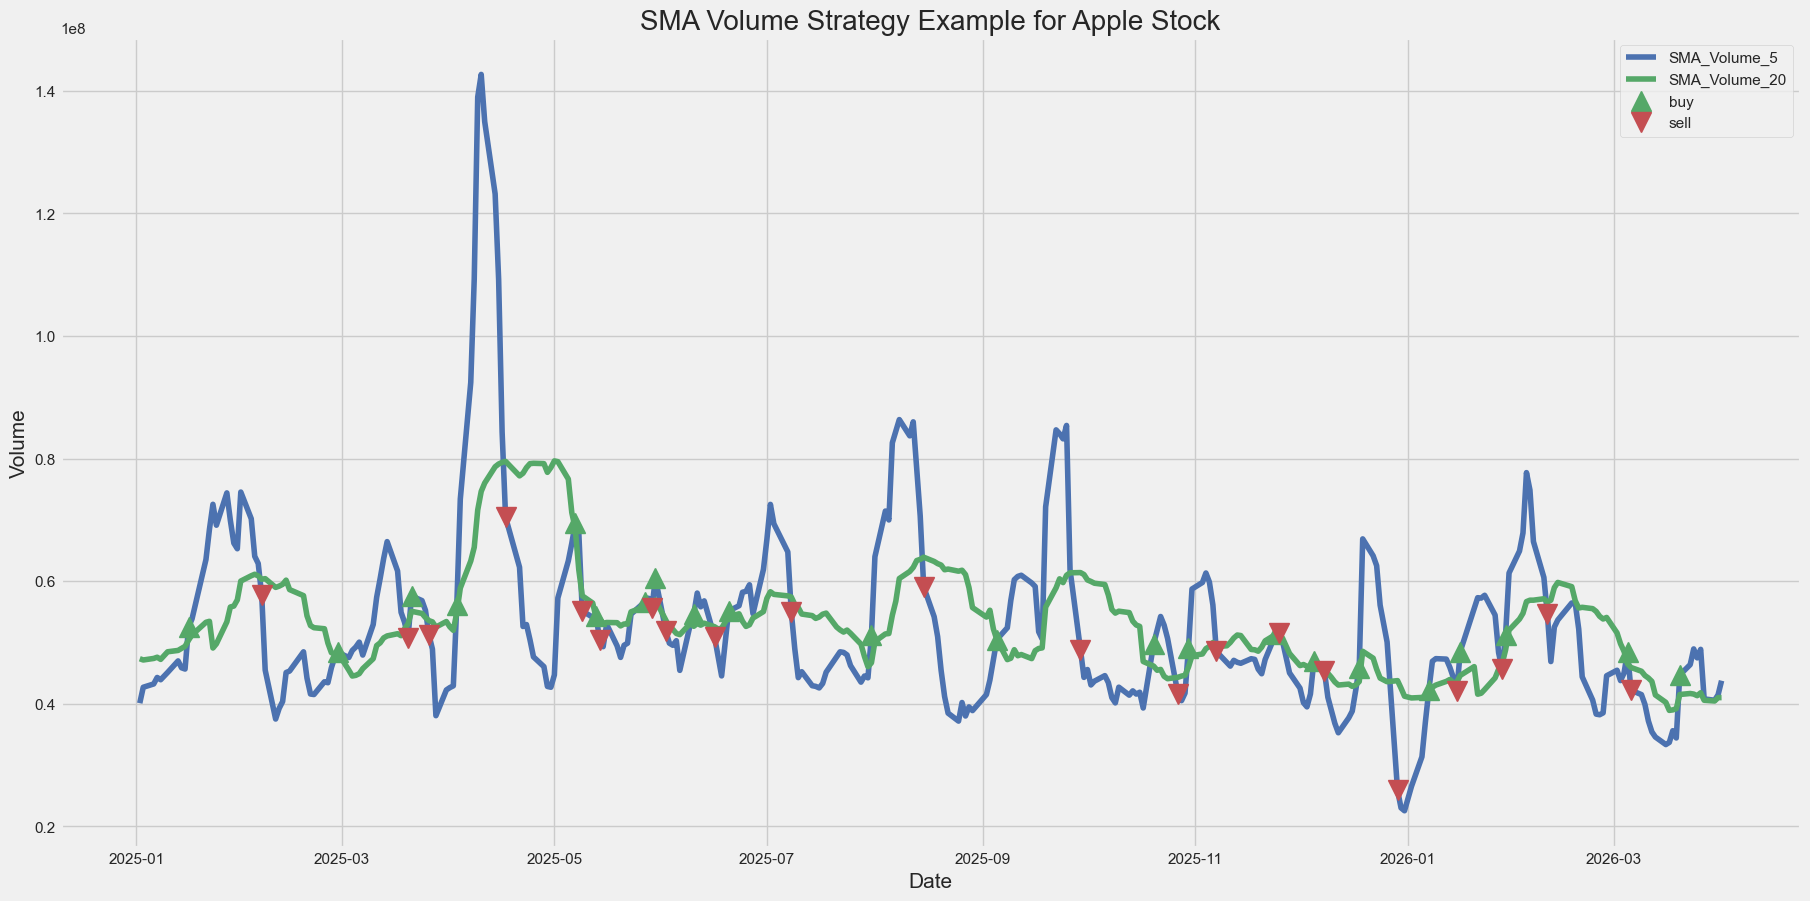

In [7]:
aapl = stocks[stocks['ticker'] == 'AAPL']
aapl = aapl[aapl.index > '2025-01-01']

plt.figure(figsize=(20, 10))

plt.plot(aapl.index, aapl['SMA_Volume_5'], color='b', label='SMA_Volume_5')
plt.plot(aapl.index, aapl['SMA_Volume_20'], color='g', label='SMA_Volume_20')

# Plot buy signals
plt.plot(aapl[aapl['SMA_Vol_Indicator_Position'] == 1].index,
         aapl['SMA_Volume_5'][aapl['SMA_Vol_Indicator_Position'] == 1],
         '^', markersize=15, color='g', label='buy')

# Plot sell signals
plt.plot(aapl[aapl['SMA_Vol_Indicator_Position'] == -1].index,
         aapl['SMA_Volume_5'][aapl['SMA_Vol_Indicator_Position'] == -1],
         'v', markersize=15, color='r', label='sell')

plt.ylabel('Volume', fontsize=15)
plt.xlabel('Date', fontsize=15)
plt.title('SMA Volume Strategy Example for Apple Stock', fontsize=20)
plt.legend()
plt.show()

## Average True Range (ATR)

In [8]:
#ATR is a measure of volatility so we want to exit when there is high volatility 
#Calculate True Range
stocks['TR'] = np.maximum((stocks['High'] - stocks['Low']), 
                     np.maximum(abs(stocks['High'] - stocks['Close'].shift(1)), 
                     abs(stocks['Low'] - stocks['Close'].shift(1))))
#Short term window ATR (1 trading week)
stocks['ATR_5'] = stocks.groupby('ticker')['TR'].transform(lambda x: x.rolling(window = 5).mean())
#Long term window Moving Avg (1 trading month)
stocks['ATR_20'] = stocks.groupby('ticker')['TR'].transform(lambda x: x.rolling(window = 20).mean())
#Check for Inflection and high volatility (when short term ATR crosses above long term), aka: when the ratio < 1
stocks['ATR_Ratio'] = stocks['ATR_20'] / stocks['ATR_5']

#Strategy:
#If ATR_Ratio < 1 THEN BUY
stocks['ATR_Indicator_Action'] = np.where(stocks['ATR_Ratio'] < 1, 1.0,0.0)
stocks['ATR_Indicator_Position'] = stocks['ATR_Indicator_Action'].diff()

### Example Plot

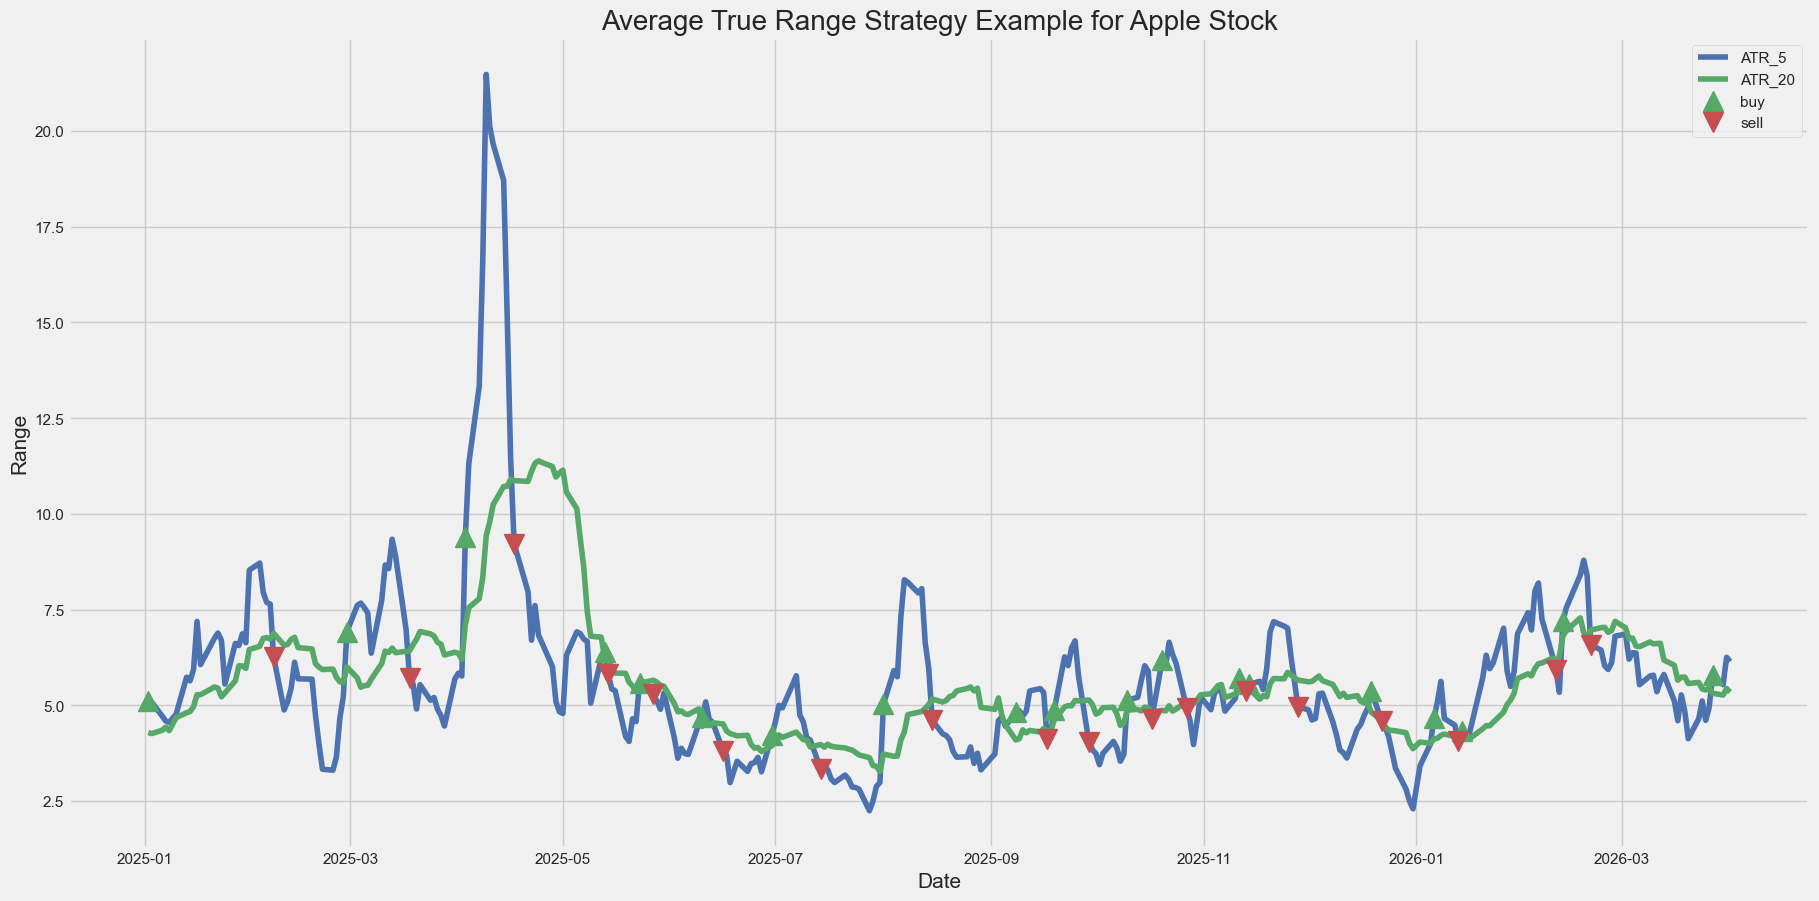

In [9]:
aapl = stocks[stocks['ticker'] == 'AAPL']
aapl = aapl[aapl.index > '2025-01-01']

plt.figure(figsize=(20, 10))

plt.plot(aapl.index, aapl['ATR_5'], color='b', label='ATR_5')
plt.plot(aapl.index, aapl['ATR_20'], color='g', label='ATR_20')

# Plot buy signals
plt.plot(aapl[aapl['ATR_Indicator_Position'] == 1].index,
         aapl['ATR_5'][aapl['ATR_Indicator_Position'] == 1],
         '^', markersize=15, color='g', label='buy')

# Plot sell signals
plt.plot(aapl[aapl['ATR_Indicator_Position'] == -1].index,
         aapl['ATR_5'][aapl['ATR_Indicator_Position'] == -1],
         'v', markersize=15, color='r', label='sell')

plt.ylabel('Range', fontsize=15)
plt.xlabel('Date', fontsize=15)
plt.title('Average True Range Strategy Example for Apple Stock', fontsize=20)
plt.legend()
plt.show()

## Stochastic Oscillators

In [10]:
#Calculate 20 day highs/lows
stocks['20Day_Low'] = stocks.groupby('ticker')['Low'].transform(lambda x: x.rolling(window = 20).min())
stocks['20Day_High'] = stocks.groupby('ticker')['High'].transform(lambda x: x.rolling(window = 20).max())
#Calculate Stochastic Oscillator Formula for %K line
stocks['20Day_%K'] = ((stocks['Close'] - stocks['20Day_Low'])/(stocks['20Day_High'] - stocks['20Day_Low']))*100
#Calculate Stochastic Oscillator Formula for %D line
stocks['20Day_%D'] = stocks['20Day_%K'].rolling(window = 3).mean()

#Strategy:
#If 20Day_%K < 30 AND 20Day_%D < 30 THEN BUY
#If 20Day_%K > 70 AND 20Day_%D > 70 THEN SELL

### Example Plot

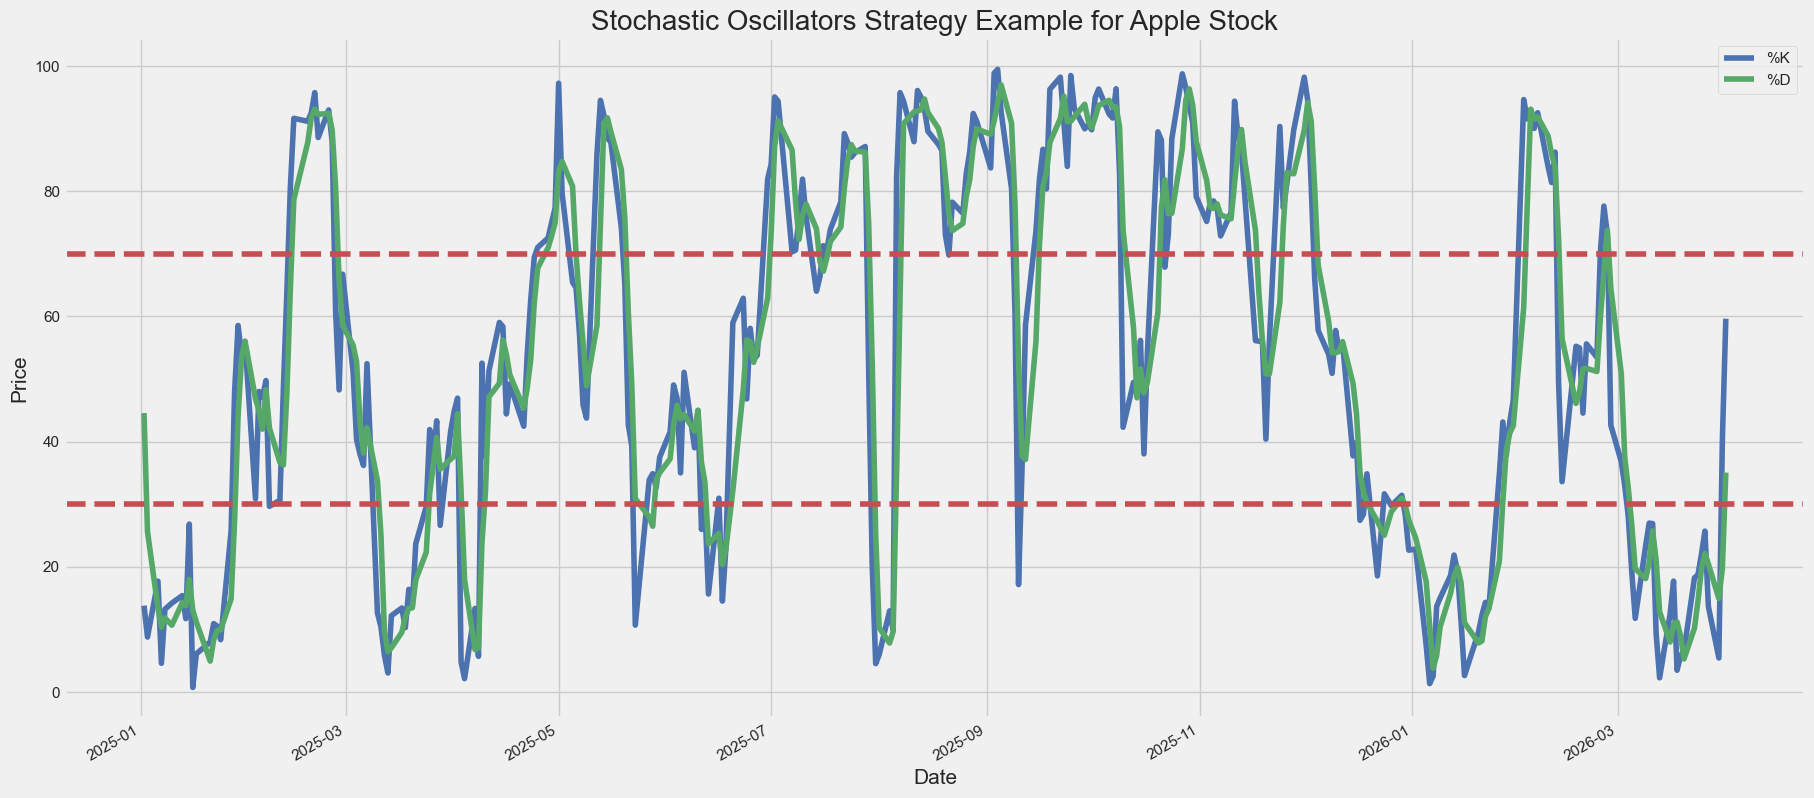

In [11]:
aapl = stocks[stocks['ticker'] == 'AAPL']
aapl = aapl[aapl.index > '2025-01-01']
plt.figure(figsize = (20,10))
# plot adjusted clost, %K and %D lines
aapl['20Day_%K'].plot(color = 'b', label= '%K') 
aapl['20Day_%D'].plot(color = 'g',label = '%D') 

plt.ylabel('Price', fontsize = 15 )
plt.xlabel('Date', fontsize = 15 )
plt.title('Stochastic Oscillators Strategy Example for Apple Stock', fontsize = 20)
plt.axhline(30, linestyle='--', color="r")
plt.axhline(70, linestyle="--", color="r")
plt.legend()
plt.show()

## Relative Strength Index (RSI)

In [12]:
# Calculate gains and losses and averages over 20 day period
stocks['diff'] = stocks.groupby('ticker')['Close'].transform(lambda x: x.diff())
stocks['gain'] = stocks['diff'].clip(lower=0).round(2)
stocks['loss'] = stocks['diff'].clip(upper=0).abs().round(2)
stocks['avg_gain20'] = stocks.groupby('ticker')['gain'].transform(lambda x: x.rolling(window=20).mean())
stocks['avg_loss20'] = stocks.groupby('ticker')['loss'].transform(lambda x: x.rolling(window=20).mean())
#Calculate RS value
stocks['RS_20'] = stocks['avg_gain20'] / stocks['avg_loss20']
#Calculate RSI value
stocks['RSI_20'] = 100 - (100/(1+stocks['RS_20']))

#Strategy:
#If RSI_20 < 30 THEN BUY
#If RSI_20 > 70 THEN SELL

### Example Plot

Text(0.5, 0, 'Date')

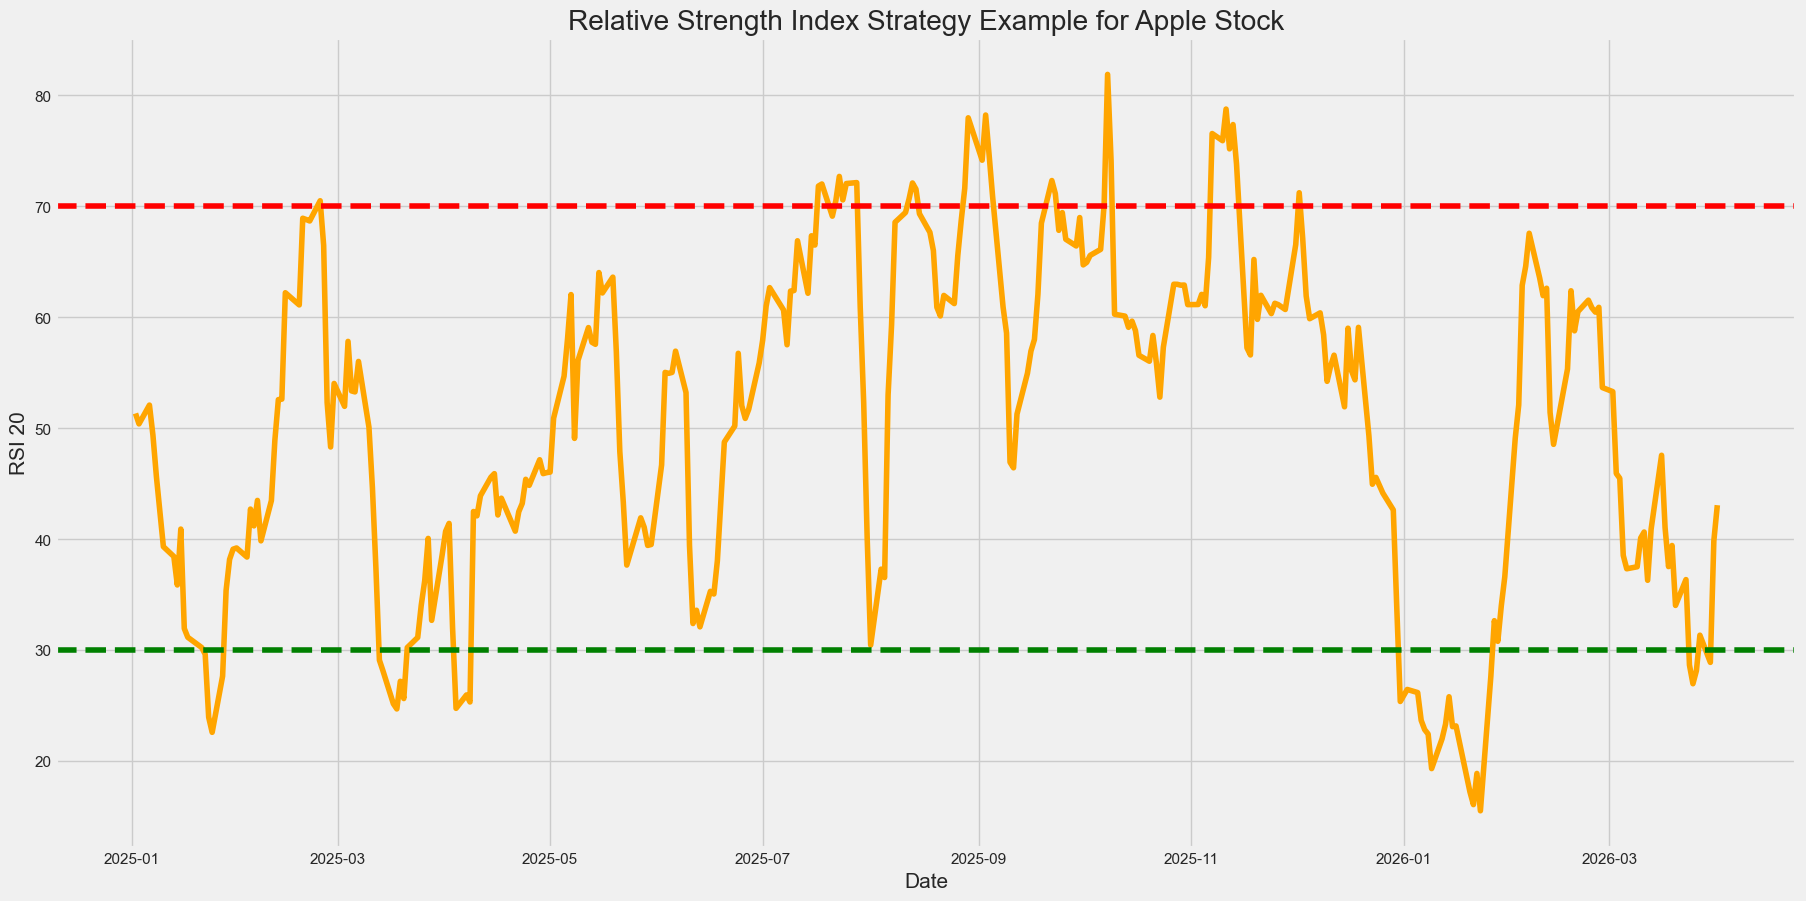

In [13]:
aapl = stocks[stocks['ticker'] == 'AAPL']
aapl = aapl[aapl.index > '2025-01-01']
plt.figure(figsize = (20,10))
# Plot the RSI
plt.title('Relative Strength Index Strategy Example for Apple Stock')
plt.plot(aapl['RSI_20'], color='orange')
# Oversold
plt.axhline(30, linestyle='--', color='green')
# Overbought
plt.axhline(70, linestyle='--', color='red')
plt.ylabel('RSI 20', fontsize = 15 )
plt.xlabel('Date', fontsize = 15 )

## Moving Average Convergence Divergence (MACD)

In [14]:
#Calculate 5 and 20 day Exponential Moving Averages
stocks['5Day_EMA'] = stocks.groupby('ticker')['Close'].transform(lambda x: x.ewm(span=5, adjust=False).mean())
stocks['20Day_EMA'] = stocks.groupby('ticker')['Close'].transform(lambda x: x.ewm(span=20, adjust=False).mean())
#Calculate MACD Value
stocks['MACD_Value'] = stocks['20Day_EMA'] - stocks['5Day_EMA']
#Calculate 5 day MACD Signal
stocks['MACD_Signal'] = stocks.groupby('ticker')['MACD_Value'].transform(lambda x: x.ewm(span=5, adjust=False).mean())

#Strategy:
#If MACD_Value > MACD_Signal THEN BUY
#If MACD_Signal > MACD_Value THEN SELL
stocks['MACD_Signal_Action'] = np.where(stocks['MACD_Value'] > stocks['MACD_Signal'], 1.0,0.0)
stocks['MACD_Signal_Position'] = stocks['MACD_Signal_Action'].diff()

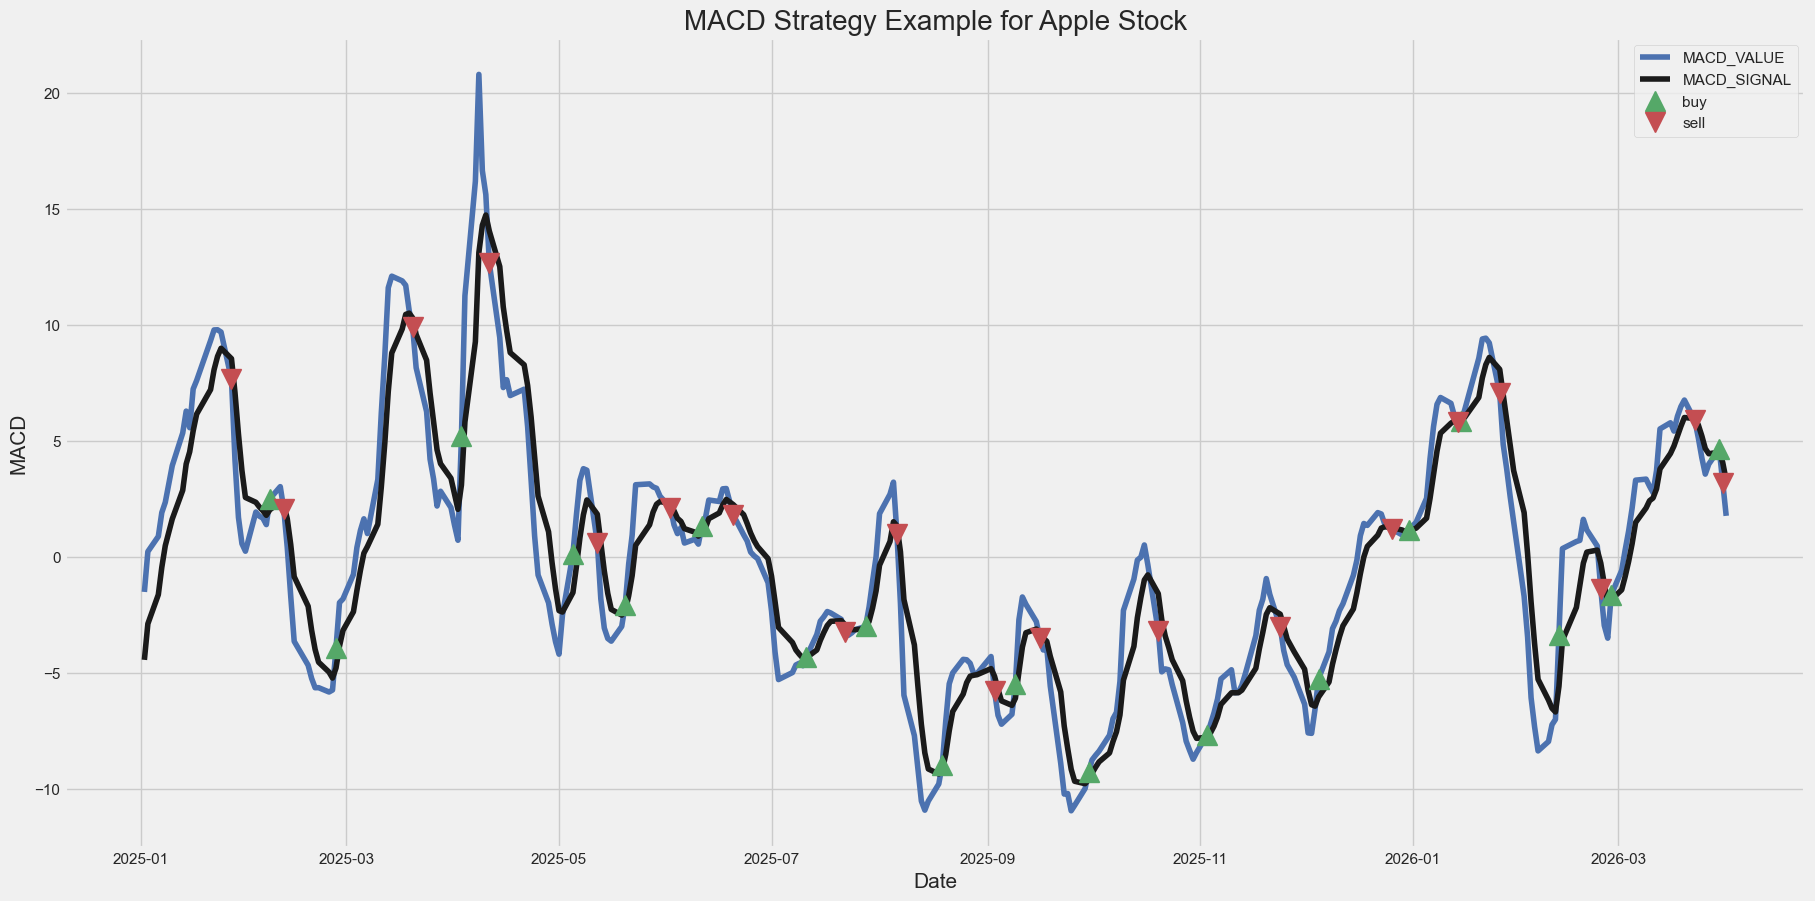

In [15]:
aapl = stocks[stocks['ticker'] == 'AAPL']
aapl = aapl[aapl.index > '2025-01-01']

plt.figure(figsize=(20, 10))

plt.plot(aapl.index, aapl['MACD_Value'], color='b', label='MACD_VALUE')
plt.plot(aapl.index, aapl['MACD_Signal'], color='k', label='MACD_SIGNAL')

# Plot buy signals
plt.plot(aapl[aapl['MACD_Signal_Position'] == 1].index,
         aapl['MACD_Value'][aapl['MACD_Signal_Position'] == 1],
         '^', markersize=15, color='g', label='buy')

# Plot sell signals
plt.plot(aapl[aapl['MACD_Signal_Position'] == -1].index,
         aapl['MACD_Value'][aapl['MACD_Signal_Position'] == -1],
         'v', markersize=15, color='r', label='sell')

plt.ylabel('MACD', fontsize=15)
plt.xlabel('Date', fontsize=15)
plt.title('MACD Strategy Example for Apple Stock', fontsize=20)
plt.legend()
plt.show()

## Bollinger Bands

In [16]:
#Calculate 20 day moving avg and std 
stocks['SMA_20'] = stocks.groupby('ticker')['Close'].transform(lambda x: x.rolling(window = 20).mean())
stocks['SD_20'] = stocks.groupby('ticker')['Close'].transform(lambda x: x.rolling(window=20).std())
#calculate upper and lower bands 
stocks['upperband'] = stocks['SMA_20'] + 2*stocks['SD_20']
stocks['lowerband'] = stocks['SMA_20'] - 2*stocks['SD_20']

#Strategy:
#If Adj Close > upperband THEN SELL
#If Adj Close < lowerband THEN BUY
stocks['Bollinger_Signal_Action'] = np.where(stocks['lowerband'] > stocks['Close'], 1.0,0.0)
stocks['Bollinger_Signal_Position'] = stocks['Bollinger_Signal_Action'].diff()

### Example Plot

<Figure size 2000x2000 with 0 Axes>

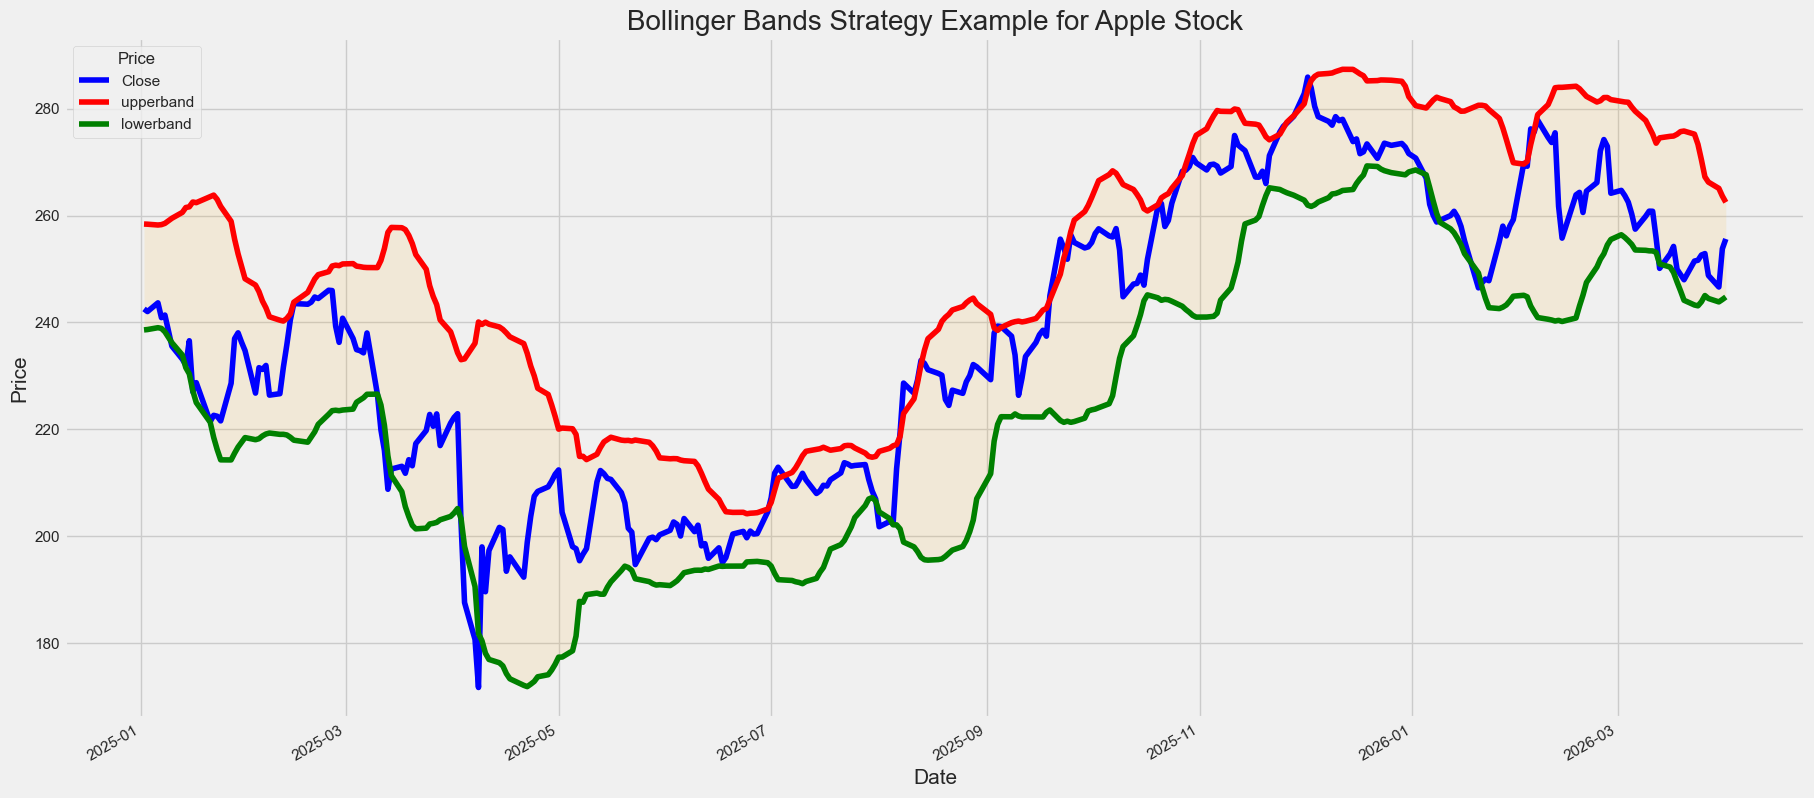

In [17]:
import pandas_datareader as pdr
import datetime as dt
import matplotlib.pyplot as plt

aapl = stocks[stocks['ticker'] == 'AAPL']
aapl = aapl[aapl.index > '2025-01-01']
plt.figure(figsize = (10,10), dpi=200)

ax = aapl[['Close', 'upperband', 'lowerband']].plot(color=['blue', 'red', 'green'])
ax.fill_between(aapl.index, aapl['lowerband'], aapl['upperband'], facecolor='orange', alpha=0.1)
plt.ylabel('Price', fontsize = 15 )
plt.xlabel('Date', fontsize = 15 )
plt.title('Bollinger Bands Strategy Example for Apple Stock', fontsize = 20)
plt.show()

In [18]:
#View complete dataframe
stocks.head(10)

Price,Close,High,Low,Open,Volume,ticker,returns,SMA_5,SMA_20,SMA_Ratio,...,20Day_EMA,MACD_Value,MACD_Signal,MACD_Signal_Action,MACD_Signal_Position,SD_20,upperband,lowerband,Bollinger_Signal_Action,Bollinger_Signal_Position
Date,,,,,,,,,,,,,,,,,,,,,
2020-01-02,334.429993,334.480011,329.170013,330.000000,1990100,ADBE,NaN,NaN,NaN,NaN,...,334.429993,0.000000,0.000000,0.0,NaN,NaN,NaN,NaN,0.0,NaN
2020-01-03,331.809998,332.980011,328.690002,329.170013,1577600,ADBE,-0.007834,NaN,NaN,NaN,...,334.180469,0.623808,0.207936,1.0,1.0,NaN,NaN,NaN,0.0,0.0
2020-01-06,333.709991,333.910004,328.190002,328.290009,1874700,ADBE,0.005726,NaN,NaN,NaN,...,334.135662,0.527891,0.314588,1.0,0.0,NaN,NaN,NaN,0.0,0.0
2020-01-07,333.390015,334.790009,332.309998,334.149994,2500800,ADBE,-0.000959,NaN,NaN,NaN,...,334.064648,0.529462,0.386213,1.0,0.0,NaN,NaN,NaN,0.0,0.0
2020-01-08,337.869995,339.230011,333.399994,333.809998,2248500,ADBE,0.013438,334.241998,NaN,NaN,...,334.427062,-0.553060,0.073122,0.0,-1.0,NaN,NaN,NaN,0.0,0.0
2020-01-09,340.450012,341.809998,338.190002,340.140015,1626300,ADBE,0.007636,335.446002,NaN,NaN,...,335.000676,-1.802743,-0.552166,0.0,0.0,NaN,NaN,NaN,0.0,0.0
2020-01-10,339.809998,343.359985,339.619995,342.049988,1480400,ADBE,-0.001880,337.046002,NaN,NaN,...,335.458707,-2.346905,-1.150413,0.0,0.0,NaN,NaN,NaN,0.0,0.0
2020-01-13,345.630005,345.730011,341.220001,341.540009,2069200,ADBE,0.017127,339.430005,NaN,NaN,...,336.427402,-3.986341,-2.095722,0.0,0.0,NaN,NaN,NaN,0.0,0.0
2020-01-14,344.630005,347.269989,343.149994,347.010010,2274400,ADBE,-0.002893,341.678003,NaN,NaN,...,337.208602,-4.610561,-2.934002,0.0,0.0,NaN,NaN,NaN,0.0,0.0


# TRADING STRATEGY

# Method:

- Combination of all Indicators (buy and sell signals)
- All Buy Signals Must be True to buy 
- One Sell Signal Must be True to sell
- Date range (2020-01-01 to present) 
 
- Create a Dataframe with profits and percentage comparisons to SPY buy and hold strategy
- Create a Dataframe with total Profit Gained, Profit Percentage, and SPY Benchmark Profit Comparison for all stocks
- Sort and rank the top 25 stocks to find out what sectors our model predicts best 
- Make a new dataframe with just these sectors 
- Calculate optimal Risk and Weighting for the portfolio 
- Calculate the total profits and final benchmark comparison 

In [19]:
# Pull SPY data directly from Yahoo Finance
spy_data = yf.download('SPY', start='2020-01-01', end=dt.date.today(), 
                        progress=False, auto_adjust=True)

# Flatten MultiIndex columns if present
if isinstance(spy_data.columns, pd.MultiIndex):
    spy_data.columns = spy_data.columns.get_level_values(0)

def benchmark_stats(starting_date, total_investment_value):
    SPY = spy_data['Close']
    benchmark = pd.DataFrame(np.diff(SPY)).rename(columns={0: 'benchmark_returns'})
    total_stocks = floor(total_investment_value / SPY.iloc[0])
    benchmark_investment_return = []

    for i in range(len(benchmark['benchmark_returns'])):
        returns = total_stocks * benchmark['benchmark_returns'].iloc[i]
        benchmark_investment_return.append(returns)

    benchmark_investment_return_df = pd.DataFrame(benchmark_investment_return).rename(columns={0: 'investment_returns'})
    return benchmark_investment_return_df

benchmark = benchmark_stats('2020-01-01', 100000)

year = '2020-01-01'
total_investment_value = 100000
total_benchmark_investment_returns = round(sum(benchmark['investment_returns']), 2)
benchmark_profit_percentage = floor((total_benchmark_investment_returns / total_investment_value) * 100)

print('Benchmark Stats from date {} to present day using an inital investment amount of ${}:'.format(year, total_investment_value))
print('Benchmark profit dollar amount ${}'.format(total_benchmark_investment_returns))
print('Benchmark profit percentage amount: {}%'.format(benchmark_profit_percentage))

returns_rows = []

for stock_ticker in stocks.ticker.unique():
    stock = stocks[(stocks['ticker'] == stock_ticker) & (stocks.index > '2020-01-01')]

    def trading_strategy(prices, SMA_Ratio, SMA_Volume_Ratio, ATR_Ratio, Day20_K, Day20_D, RSI_20, MACD_Value, MACD_Signal, upperband, lowerband):
        buy_price = []
        sell_price = []
        trading_signal = []
        signal = 0

        for i in range(len(prices)):
            if (SMA_Ratio.iloc[i] < 1) & (SMA_Volume_Ratio.iloc[i] < 1) & (ATR_Ratio.iloc[i] < 1) \
            & (Day20_K.iloc[i] < 30) & (Day20_D.iloc[i] < 30) & (RSI_20.iloc[i] < 30) \
            & (MACD_Value.iloc[i] > MACD_Signal.iloc[i]) & (prices.iloc[i] < lowerband.iloc[i]):
                if signal != 1:
                    buy_price.append(prices.iloc[i])
                    sell_price.append(np.nan)
                    signal = 1
                    trading_signal.append(signal)
                else:
                    buy_price.append(np.nan)
                    sell_price.append(np.nan)
                    trading_signal.append(0)

            elif (SMA_Ratio.iloc[i] > 1) | (SMA_Volume_Ratio.iloc[i] > 1) | (ATR_Ratio.iloc[i] > 1) \
            | (Day20_K.iloc[i] > 70) | (Day20_D.iloc[i] > 70) | (RSI_20.iloc[i] > 70) \
            | (MACD_Value.iloc[i] < MACD_Signal.iloc[i]) | (prices.iloc[i] > upperband.iloc[i]):
                if signal != -1 and signal != 0:
                    buy_price.append(np.nan)
                    sell_price.append(prices.iloc[i])
                    signal = -1
                    trading_signal.append(signal)
                else:
                    buy_price.append(np.nan)
                    sell_price.append(np.nan)
                    trading_signal.append(0)
            else:
                buy_price.append(np.nan)
                sell_price.append(np.nan)
                trading_signal.append(0)

        return buy_price, sell_price, trading_signal

    buy_price, sell_price, trading_signal = trading_strategy(
        stock['Close'], stock['SMA_Ratio'], stock['SMA_Volume_Ratio'],
        stock['ATR_Ratio'], stock['20Day_%K'], stock['20Day_%D'], stock['RSI_20'],
        stock['MACD_Value'], stock['MACD_Signal'], stock['upperband'], stock['lowerband']
    )

    position = []
    for i in range(len(trading_signal)):
        if trading_signal[i] > 1:
            position.append(0)
        else:
            position.append(1)

    for i in range(len(stock['Close'])):
        if trading_signal[i] == 1:
            position[i] = 1
        elif trading_signal[i] == -1:
            position[i] = 0
        else:
            position[i] = position[i-1]

    close_price = stock['Close']
    SMA_ratio = stock['SMA_Ratio']
    SMA_Volume_Ratio = stock['SMA_Volume_Ratio']
    ATR_Ratio = stock['ATR_Ratio']
    Day20_K = stock['20Day_%K']
    Day20_D = stock['20Day_%D']
    RSI_20 = stock['RSI_20']
    MACD_Value = stock['MACD_Value']
    MACD_Signal = stock['MACD_Signal']
    upperband = stock['upperband']
    lowerband = stock['lowerband']
    trading_signal = pd.DataFrame(trading_signal).rename(columns={0: 'trading_signal'}).set_index(stock.index)
    position = pd.DataFrame(position).rename(columns={0: 'trading_position'}).set_index(stock.index)

    frames = [close_price, SMA_ratio, SMA_Volume_Ratio, ATR_Ratio, Day20_K, Day20_D,
              RSI_20, MACD_Value, MACD_Signal, upperband, lowerband, trading_signal, position]
    strategy = pd.concat(frames, join='inner', axis=1)

    stock_ret = pd.DataFrame(np.diff(stock['Close'])).rename(columns={0: 'returns'})
    trading_strategy_ret = []

    for i in range(len(stock_ret)):
        try:
            returns = stock_ret['returns'].iloc[i] * strategy['trading_position'].iloc[i]
            trading_strategy_ret.append(returns)
        except:
            pass

    trading_strategy_ret_df = pd.DataFrame(trading_strategy_ret).rename(columns={0: 'trading_returns'})

    investment_value = 100000
    number_of_stocks = floor(investment_value / stock['Close'].iloc[0])
    trading_investment_ret = []

    for i in range(len(trading_strategy_ret_df['trading_returns'])):
        returns = number_of_stocks * trading_strategy_ret_df['trading_returns'].iloc[i]
        trading_investment_ret.append(returns)

    trading_investment_ret_df = pd.DataFrame(trading_investment_ret).rename(columns={0: 'investment_returns'})
    total_investment_ret = round(sum(trading_investment_ret_df['investment_returns']), 2)
    profit_percentage = floor((total_investment_ret / investment_value) * 100)
    benchmark_comparison = profit_percentage - benchmark_profit_percentage

    returns_rows.append({
        'Ticker': stock_ticker,
        'Profit Gained': total_investment_ret,
        'Profit Percentage': profit_percentage,
        'Benchmark Profit Comparison': benchmark_comparison
    })

returns_df = pd.DataFrame(returns_rows)
returns_df

Benchmark Stats from date 2020-01-01 to present day using an inital investment amount of $100000:
Benchmark profit dollar amount $120406.22
Benchmark profit percentage amount: 120%


,Ticker,Profit Gained,Profit Percentage,Benchmark Profit Comparison
0,ADBE,-27824.94,-28,-148
1,AMD,328019.98,328,208
2,ABNB,-13488.32,-14,-134
3,ALNY,184127.05,184,64
4,GOOGL,338078.52,338,218
...,...,...,...,...
96,WBD,-14677.19,-15,-135
97,WDC,510662.80,510,390
98,WDAY,-22930.77,-23,-143
99,XEL,54815.77,54,-66


In [20]:
#Add Sector Information for each Ticker
ticker = []
sector = []
for i in returns_df.Ticker.unique():
    ticker.append(i)
    tickerdata = yf.Ticker(i)
    s = tickerdata.info['sector']
    sector.append(s)
sector_df = pd.DataFrame(
    {'Ticker': ticker,
     'Sector': sector})
returns_df = pd.merge(returns_df, sector_df, on='Ticker')
returns_df

,Ticker,Profit Gained,Profit Percentage,Benchmark Profit Comparison,Sector
0,ADBE,-27824.94,-28,-148,Technology
1,AMD,328019.98,328,208,Technology
2,ABNB,-13488.32,-14,-134,Consumer Cyclical
3,ALNY,184127.05,184,64,Healthcare
4,GOOGL,338078.52,338,218,Communication Services
...,...,...,...,...,...
96,WBD,-14677.19,-15,-135,Communication Services
97,WDC,510662.80,510,390,Technology
98,WDAY,-22930.77,-23,-143,Technology
99,XEL,54815.77,54,-66,Utilities


In [21]:
#Sort the dataframe by profit 
ranked_df = returns_df.sort_values(['Profit Gained'], ascending=False)[:25]

#Print sector value counts
print('Top 25 Performing Sectors: ')
print(ranked_df.Sector[:25].value_counts())
print()
print('Total Inital Sector Counts: ')
print(returns_df.Sector.value_counts())
print()
#Model is best at predicting communication services, make a porfolio of only those companies
print('Ratios to determine true best performing sectors: ')
print('Technology:              (17/41)=', 17/41 )
print('Consumer_Cyclical:       (1/11)=', 1/11)
print('Communication_Services:  (3/11)=', 3/11 )
print('Healthcare:              (1/10)=', 1/10)
print('Industrials:             (1/11)=', 1/11)
print('Consumer Defense:        (1/8)=', 1/8)

Top 25 Performing Sectors: 
Sector
Technology                17
Communication Services     3
Consumer Cyclical          1
Healthcare                 1
Utilities                  1
Industrials                1
Consumer Defensive         1
Name: count, dtype: int64

Total Inital Sector Counts: 
Sector
Technology                41
Consumer Cyclical         11
Communication Services    11
Industrials               11
Healthcare                10
Consumer Defensive         8
Utilities                  4
Energy                     2
Real Estate                1
Basic Materials            1
Financial Services         1
Name: count, dtype: int64

Ratios to determine true best performing sectors: 
Technology:              (17/41)= 0.4146341463414634
Consumer_Cyclical:       (1/11)= 0.09090909090909091
Communication_Services:  (3/11)= 0.2727272727272727
Healthcare:              (1/10)= 0.1
Industrials:             (1/11)= 0.09090909090909091
Consumer Defense:        (1/8)= 0.125


In [22]:
#Best pertforming sector by far is Technology and then Communication Services
#Create a new portfolio with only Technology and Communication Services Stocks from the NASDAQ 100
portfolio_df = returns_df[(returns_df.Sector == 'Technology') | (returns_df.Sector == 'Communication Services')]
portfolio_df

,Ticker,Profit Gained,Profit Percentage,Benchmark Profit Comparison,Sector
0,ADBE,-27824.94,-28,-148,Technology
1,AMD,328019.98,328,208,Technology
4,GOOGL,338078.52,338,218,Communication Services
5,GOOG,334728.05,334,214,Communication Services
9,ADI,197254.77,197,77,Technology
10,AAPL,253039.91,253,133,Technology
11,AMAT,502556.20,502,382,Technology
12,APP,494607.12,494,374,Communication Services
13,ARM,143806.57,143,23,Technology
14,ASML,374558.95,374,254,Technology


Text(0.5, 1.0, 'Efficient Frontier')

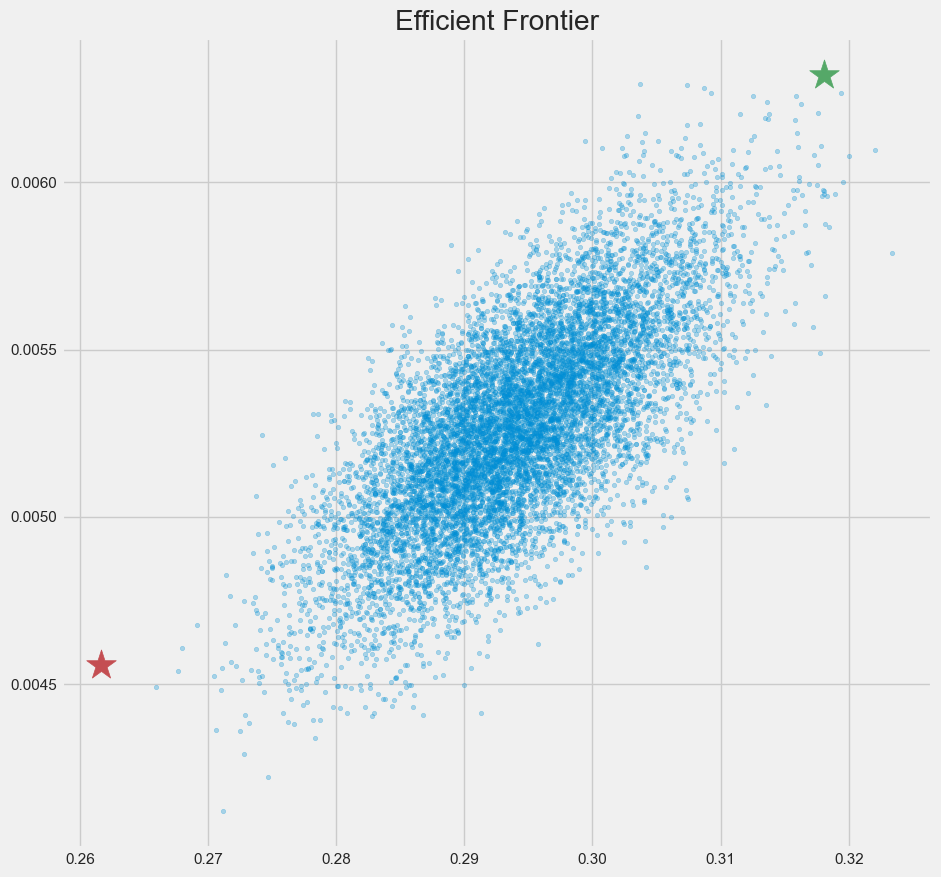

In [23]:
#Portfolio Risk, Weighting Calculations

portfolio_tickers = list(portfolio_df.Ticker.unique())
risk_df = stocks[(stocks.ticker.isin(portfolio_tickers)) & (stocks.index >= '2020-01-01')]

stocks_min_risk = risk_df[['ticker','Close']]
stocks_min_risk = pd.pivot(stocks_min_risk,columns = 'ticker', values = 'Close')

cov_matrix = stocks_min_risk.pct_change().apply(lambda x: np.log(1+x)).cov()
corr_matrix = stocks_min_risk.pct_change().apply(lambda x: np.log(1+x)).corr()


# weekly returns for individual companies
ind_er = stocks_min_risk.resample('W').last().pct_change().mean()


p_ret = [] # portfolio returns
p_vol = [] # portfolio volatility
p_weights = [] # asset weights

num_assets = len(stocks_min_risk.columns)
num_portfolios = 10000


for portfolio in range(num_portfolios):
    weights = np.random.random(num_assets)
    weights = weights/np.sum(weights)
    p_weights.append(weights)
    returns = np.dot(weights, ind_er)    
    p_ret.append(returns)
    var = cov_matrix.mul(weights, axis=0).mul(weights, axis=1).sum().sum()
    sd = np.sqrt(var)
    ann_sd = sd*np.sqrt(250) 
    p_vol.append(ann_sd)

data1 = {'Returns':p_ret, 'Volatility':p_vol}

for counter, symbol in enumerate(stocks_min_risk.columns.tolist()):
    data1[symbol+' weight'] = [w[counter] for w in p_weights]
portfolios  = pd.DataFrame(data1)
portfolios.head()

min_vol_port = portfolios.iloc[portfolios['Volatility'].idxmin()]
               
rf = 0.01 
optimal_risky_port = portfolios.iloc[((portfolios['Returns']-rf)/portfolios['Volatility']).idxmax()]

plt.subplots(figsize=(10, 10))
plt.scatter(portfolios['Volatility'], portfolios['Returns'], marker='o', s=10, alpha=0.3)
plt.scatter(min_vol_port['Volatility'], min_vol_port['Returns'], color='r', marker='*', s=500)
plt.scatter(optimal_risky_port['Volatility'], optimal_risky_port['Returns'], color='g', marker='*', s=500)
plt.title("Efficient Frontier")

In [24]:
#Minimum Volatility Weight
min_vol_port = portfolios.iloc[portfolios['Volatility'].idxmin()]

# Maximum Return Weight
# Finding the optimal portfolio
rf = 0.01 # risk factor
optimal_risky_port = portfolios.iloc[((portfolios['Returns']-rf)/portfolios['Volatility']).idxmax()]
print('Maximum Return Weight: ')
print(optimal_risky_port)

Maximum Return Weight: 
Returns         0.006321
Volatility      0.318043
AAPL weight     0.005503
ADBE weight     0.010759
ADI weight      0.015271
ADP weight      0.028437
ADSK weight     0.010425
AMAT weight     0.039500
AMD weight      0.008039
APP weight      0.015366
ARM weight      0.024325
ASML weight     0.025002
AVGO weight     0.017616
CDNS weight     0.026206
CHTR weight     0.007744
CMCSA weight    0.008126
CRWD weight     0.025953
CSCO weight     0.009383
CTSH weight     0.005504
DDOG weight     0.036620
EA weight       0.014316
FTNT weight     0.025821
GOOG weight     0.012768
GOOGL weight    0.007390
INTC weight     0.026883
INTU weight     0.014167
KLAC weight     0.030560
LRCX weight     0.016700
MCHP weight     0.008446
META weight     0.018688
MPWR weight     0.039744
MRVL weight     0.019197
MSFT weight     0.003031
MSTR weight     0.025191
MU weight       0.034982
NFLX weight     0.017146
NVDA weight     0.035387
NXPI weight     0.034500
PANW weight     0.024799
P

In [25]:
#Add weights to final portfolio
portfolio_df = portfolio_df.sort_values('Ticker')
ticker_list = list(portfolio_df.Ticker)
weight_list = list(optimal_risky_port[2:])
weight_dict = dict(zip(ticker_list, weight_list))
weight_df = pd.DataFrame(weight_dict.items(), columns=['Ticker', 'Weight'])
final_portfolio_df = pd.merge(portfolio_df, weight_df, on='Ticker', how='outer')
final_portfolio_df

,Ticker,Profit Gained,Profit Percentage,Benchmark Profit Comparison,Sector,Weight
0,AAPL,253039.91,253,133,Technology,0.005503
1,ADBE,-27824.94,-28,-148,Technology,0.010759
2,ADI,197254.77,197,77,Technology,0.015271
3,ADP,35363.62,35,-85,Technology,0.028437
4,ADSK,26621.28,26,-94,Technology,0.010425
5,AMAT,502556.20,502,382,Technology,0.039500
6,AMD,328019.98,328,208,Technology,0.008039
7,APP,494607.12,494,374,Communication Services,0.015366
8,ARM,143806.57,143,23,Technology,0.024325
9,ASML,374558.95,374,254,Technology,0.025002


In [26]:
#Multiply weights by profit statistics 
final_portfolio_df['Profit Gained'] = final_portfolio_df['Profit Gained'] * final_portfolio_df['Weight']
final_portfolio_df['Profit Percentage'] = final_portfolio_df['Profit Percentage'] * final_portfolio_df['Weight']
final_portfolio_df['Benchmark Profit Comparison'] = final_portfolio_df['Benchmark Profit Comparison'] * final_portfolio_df['Weight']
final_portfolio_df

,Ticker,Profit Gained,Profit Percentage,Benchmark Profit Comparison,Sector,Weight
0,AAPL,1392.584715,1.392365,0.731955,Technology,0.005503
1,ADBE,-299.381469,-0.301265,-1.592401,Technology,0.010759
2,ADI,3012.200352,3.008310,1.175837,Technology,0.015271
3,ADP,1005.625977,0.995286,-2.417123,Technology,0.028437
4,ADSK,277.530561,0.271054,-0.979963,Technology,0.010425
5,AMAT,19850.790623,19.828821,15.088864,Technology,0.039500
6,AMD,2636.826216,2.636666,1.672032,Technology,0.008039
7,APP,7600.144863,7.590816,5.746893,Communication Services,0.015366
8,ARM,3498.093953,3.478474,0.559475,Technology,0.024325
9,ASML,9364.555433,9.350581,6.350394,Technology,0.025002


In [27]:
#Calculate Total Benchmark Profit Comparison of our Final weighted portfolio 
print('Our trading strategy outperformed a buy and hold SPY strategy over the years 2020-01-01 to present day by', round(final_portfolio_df['Benchmark Profit Comparison'].sum(),2), '%')

Our trading strategy outperformed a buy and hold SPY strategy over the years 2020-01-01 to present day by 311.86 %
